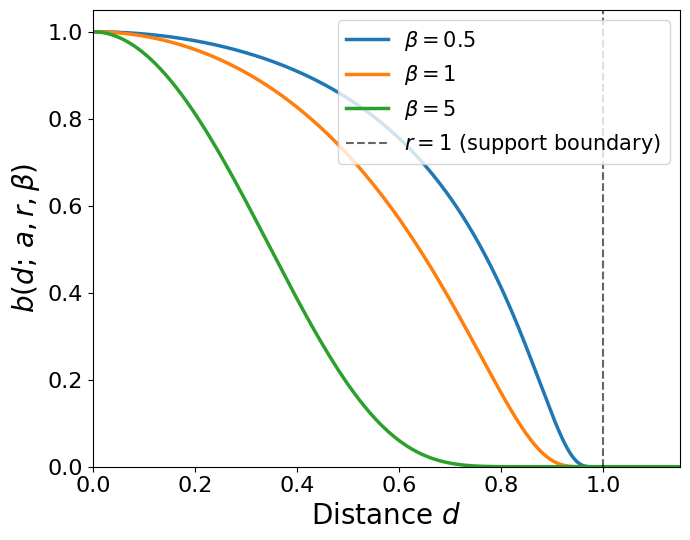

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def bump_function(d, a, r, beta):
    """
    Compactly supported bump function, Eq. (4):
        b(d; a, r, beta) = a * exp( -beta / (1 - d^2/r^2) + beta )   if d < r
                          = 0                                        otherwise
    """
    d = np.asarray(d, dtype=float)
    out = np.zeros_like(d)
    inside = d < r
    dd = d[inside]
    out[inside] = a * np.exp(-beta / (1.0 - (dd**2 / r**2)) + beta)
    return out


# ── Fixed parameters ───────────────────────────────────────────────────────
a = 1.0        # amplitude
r = 1.0        # support radius
beta_values = [0.5, 1.0, 5.0]
colors = ['tab:blue', 'tab:orange', 'tab:green']

# ── Distance grid ───────────────────────────────────────────────────────────
# Slightly overshoot r so the compact support (drop to zero at d=r) is visible
d = np.linspace(0.0, 1.15 * r, 2000)

# ── Plot ─────────────────────────────────────────────────────────────────
Font_Size = 20
Tick_Size = 16
Legend_Size = 15

fig, ax = plt.subplots(figsize=(7, 5.5))

for beta, color in zip(beta_values, colors):
    b_vals = bump_function(d, a, r, beta)
    ax.plot(d, b_vals, linewidth=2.5, color=color, label=rf'$\beta = {beta:g}$')

# Mark the support boundary r
ax.axvline(r, color='black', linestyle='--', alpha=0.6, linewidth=1.5,
           label=rf'$r = {r:g}$ (support boundary)')

ax.set_xlabel(r'Distance $d$', fontsize=Font_Size)
ax.set_ylabel(r'$b(d;\, a, r, \beta)$', fontsize=Font_Size)
ax.tick_params(axis='both', labelsize=Tick_Size)
ax.legend(fontsize=Legend_Size, loc='upper right')
ax.set_xlim(0, 1.15 * r)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('bump_function_visualization.pdf', dpi=150, bbox_inches='tight')
plt.show()